# Paper figures — interactive driver

Each figure lives as a function in `lora_playground/plotting/paper_figs.py` (`fig1`, `table1`, `figA_breadth`, `figA_breadth_math`, `figA_rank`, `fig_ood`, `fig2`, `fig3`). `%autoreload` picks up edits to that module — edit the function, rerun the cell, the re-rendered PNG displays below (PDF + PNG are written to `paper/manuscript/figs/`).

In [8]:
%load_ext autoreload
%autoreload 2

from lora_playground.plotting import paper_figs as bpf
from IPython.display import Image, display

FIGS = bpf.FIGS

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Figure 1 — showcase: loss vs steps, Llama-3.2-1B openmath r=256

AdamW, iMuon, LoRA-RITE, Muon, and Polar-LoRA, each at its best lr (all solid). The blue dashed span at AdamW's final loss runs from where Polar-LoRA reaches that loss to the horizon; its length is the steps Polar-LoRA saves, stated in the boxed callout.

── fig1: Llama-3.2-1B / OpenMathInstruct-2 / r=256  target 0.3823  crossing step 5529  speedup x1.63  arms: ['AdamW', 'LoRA-RITE', 'Muon', 'PoLoRA', 'iMuon']


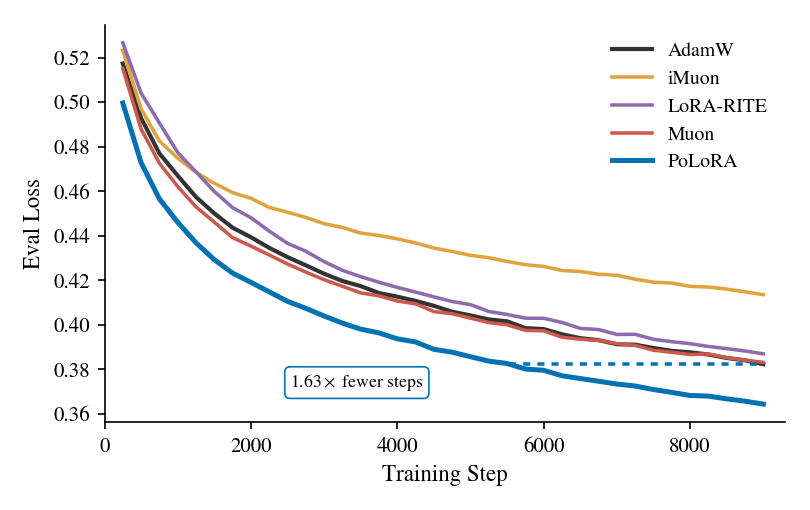

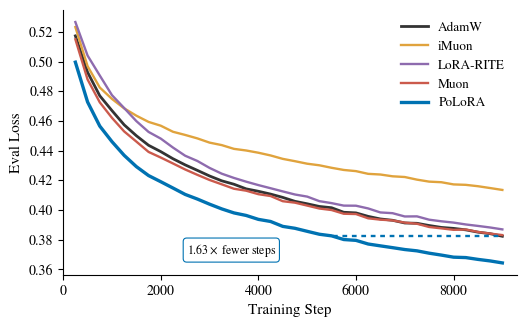

In [9]:
bpf.fig1()
display(Image(str(FIGS / 'fig1_hero.png')))

## Tables — per-cell step-speedup-to-AdamW (LaTeX includes)

`tab_breadth` / `tab_breadth_math` (model breadth, code & math, r=256), `tab_rank` (Llama openmath rank ladder), `tab_ood` (Qwen code vs Bengali). The manuscript's merged code+math `tab:breadth` pairs these step numbers with bench-measured wall-clock.

In [10]:
bpf.table1()
for t in ("tab_breadth", "tab_breadth_math", "tab_rank", "tab_ood"):
    print(f"=== {t}.tex ===")
    print((FIGS / f"{t}.tex").read_text())

── speedup table data ──
  ('OLMo-2-1B', 'Math', 256)  x1.74 / x1.50
  ('Qwen2.5-1.5B', 'Bengali', 256)  x1.73 / x1.39
  ('Qwen2.5-1.5B', 'Math', 256)  x1.64 / x1.33
  ('Llama-3.2-1B', 'Math', 256)  x1.63 / x1.40
    iMuon @ Llama-3.2-1B / OpenMathInstruct-2 / r=256 <1x (no crossing)
  ('OLMo-2-1B', 'Code', 256)  x1.61 / x1.26
    iMuon @ OLMo-2-1B / opc-sft-stage2 / r=256     x1.01
  ('Llama-3-8B', 'Math', 256)  x1.59 / x1.25
  ('Llama-3.2-1B', 'Code', 256)  x1.55 / x1.24
  ('Llama-3.2-1B', 'Math', 64)  x1.54 / x1.25
  ('Llama-3.2-1B', 'Math', 128)  x1.52 / x1.28
  ('Llama-3.2-1B', 'Math', 32)  x1.48 / x1.23
  ('Qwen2.5-1.5B', 'Code', 256)  x1.30 / x1.08
  ('Llama-3-8B', 'Code', 256)  x1.20 / x1.09
=== tab_breadth.tex ===
\begin{tabular}{lr}
\toprule
model (code, $r{=}256$) & speedup \\
\midrule
OLMo-2-1B & 1.61$\times$ \\
Llama-3.2-1B & 1.55$\times$ \\
Qwen2.5-1.5B & 1.30$\times$ \\
Llama-3-8B & 1.20$\times$ \\
\bottomrule
\end{tabular}

=== tab_breadth_math.tex ===
\begin{tabular}{l

── fig_ood (Qwen2.5-1.5B r256 task pair) ──
  Code (in-distribution)         target 0.6023  crossing step 6909  speedup x1.30
  Bengali (out-of-distribution)  target 0.4979  crossing step 5188  speedup x1.73


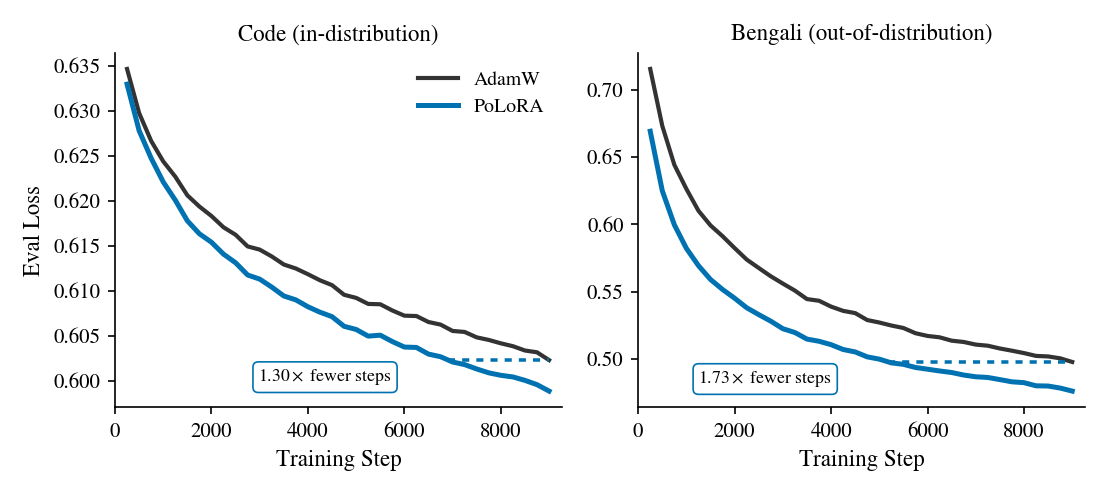

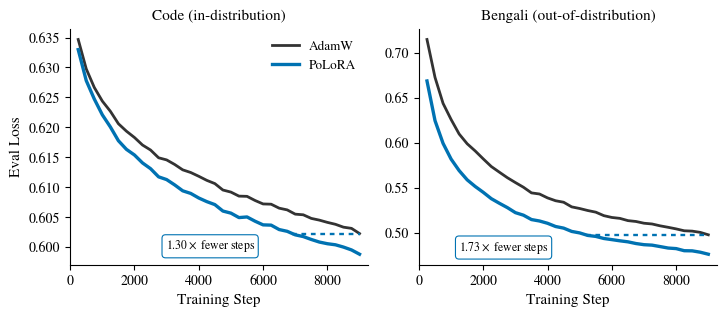

In [11]:
bpf.fig_ood()
display(Image(str(FIGS / 'fig_ood.png')))

## Appendix figures — per-setting learning curves (tail-zoom grid)

One panel per cell, AdamW vs Polar-LoRA at each one's best lr; crossing fraction of the horizon printed at each drop-line. Model breadth on code (`figA_breadth`) and math (`figA_breadth_math`), and the Llama openmath rank ladder (`figA_rank`). Each excludes the cells already drawn in the body.

── figA_breadth ──
  OLMo-2-1B        target 0.7524  crossing 5587  x1.61
  Llama-3.2-1B     target 0.6948  crossing 5820  x1.55
  Llama-3-8B       target 0.5553  crossing 7523  x1.20


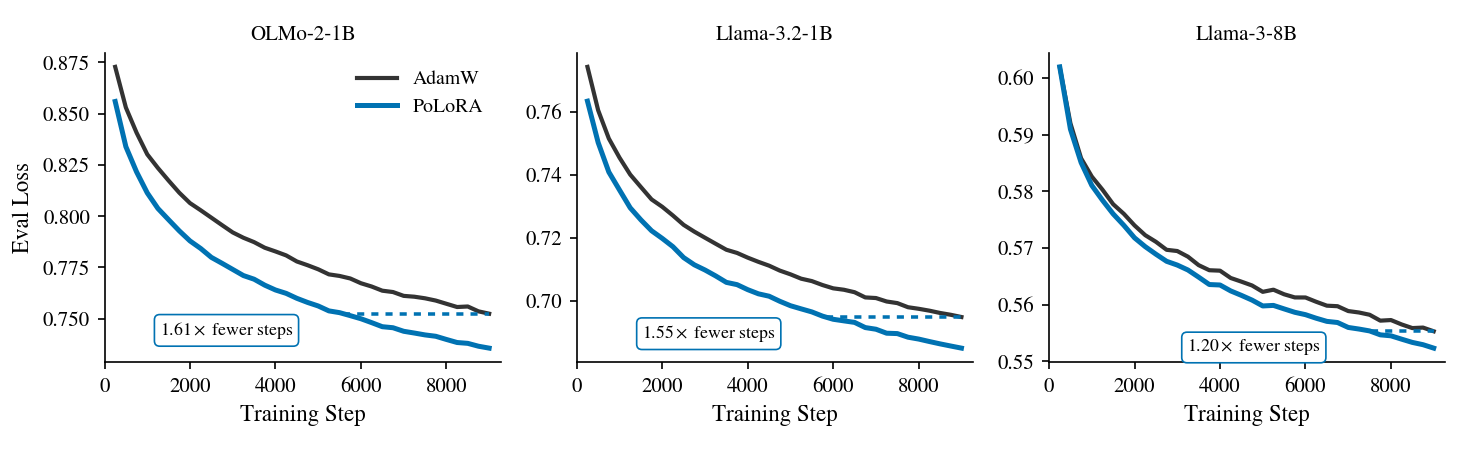

── figA_breadth_math ──
  OLMo-2-1B        target 0.3964  crossing 5164  x1.74
  Qwen2.5-1.5B     target 0.2935  crossing 5499  x1.64
  Llama-3-8B       target 0.2866  crossing 5678  x1.59


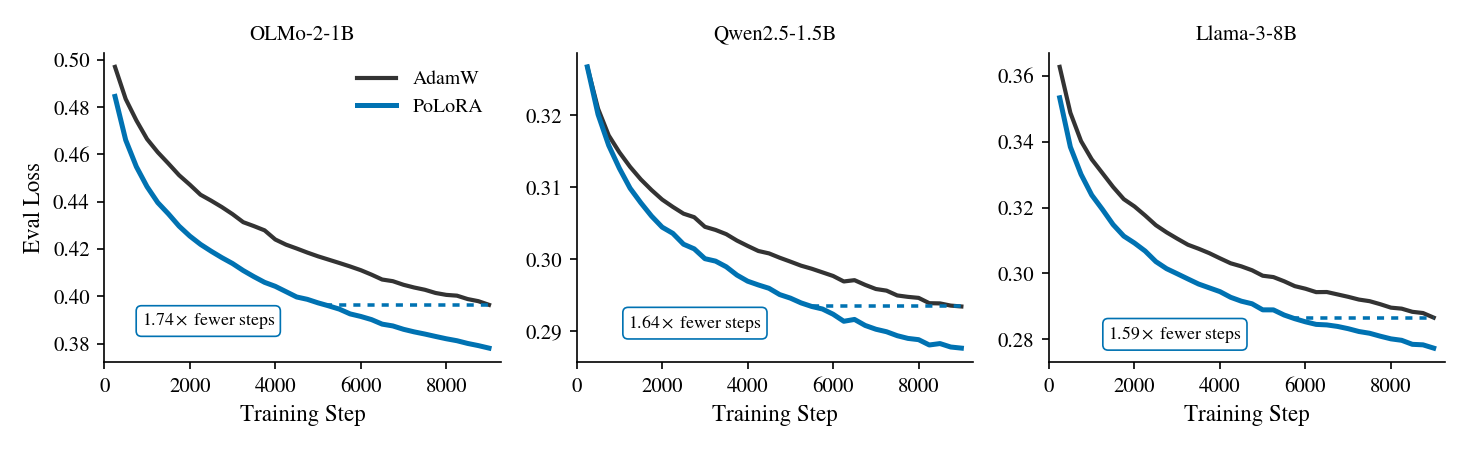

── figA_rank ──
  $r=32$           target 0.4115  crossing 6081  x1.48
  $r=64$           target 0.3991  crossing 5829  x1.54
  $r=128$          target 0.3890  crossing 5910  x1.52


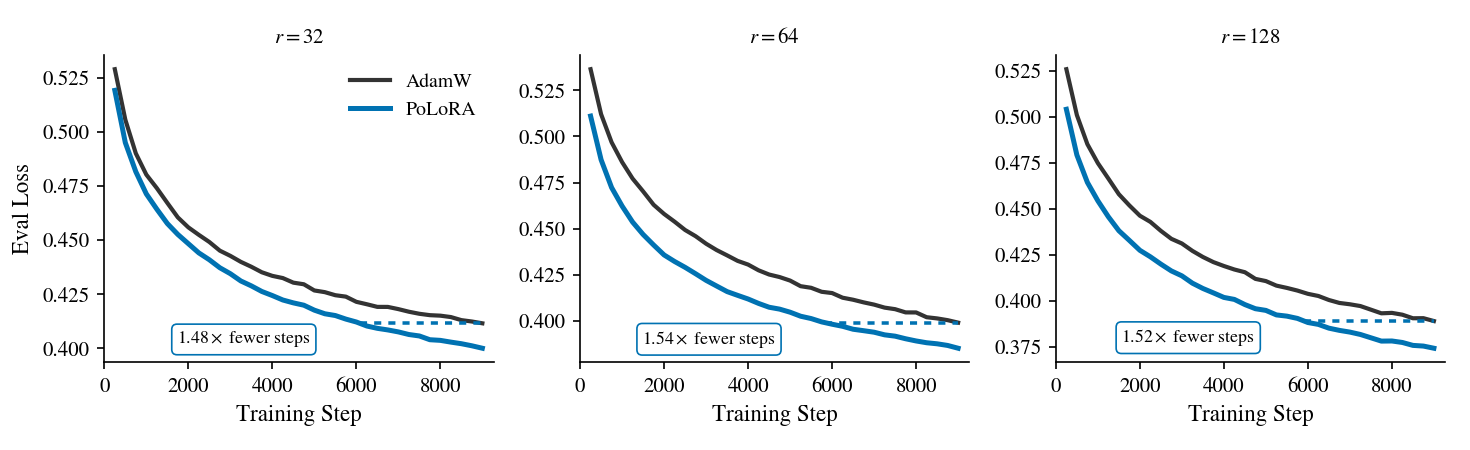

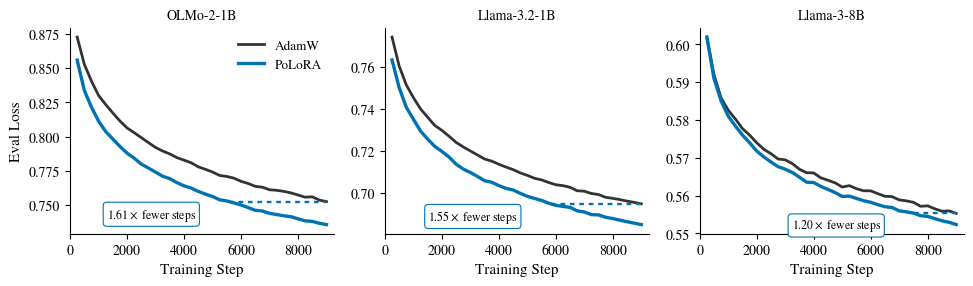

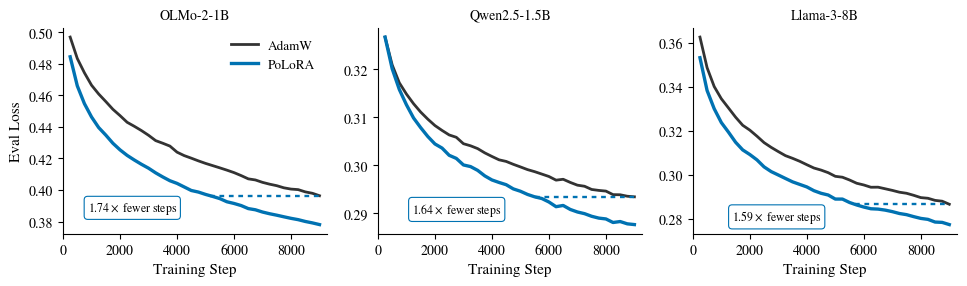

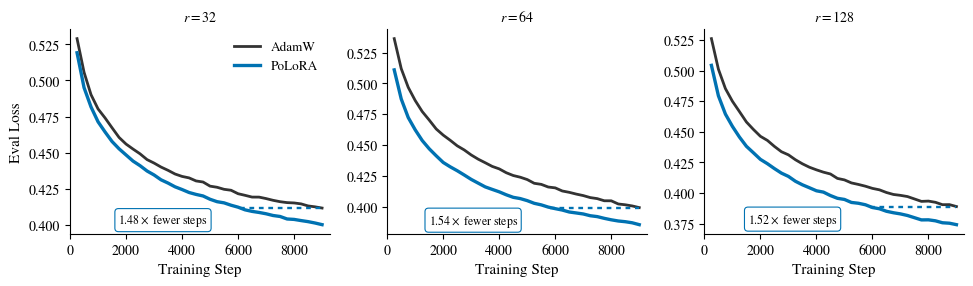

In [12]:
bpf.figA_breadth()
display(Image(str(FIGS / 'figA_breadth.png')))
bpf.figA_breadth_math()
display(Image(str(FIGS / 'figA_breadth_math.png')))
bpf.figA_rank()
display(Image(str(FIGS / 'figA_rank.png')))

## Figure 2 — leave-one-out basins, Llama-3.2-1B openmath r=256

Final loss vs lr for Polar-LoRA / w/o curvature control / w/o magnitude control; ring = each arm's best lr; gray band = sigma_ref above the best final.

── fig2 (left) ablation curves (openmath r256) ──
  w/o curvature + magnitude best_lr 0.001  final 0.3815
  w/o curvature            best_lr 0.003  final 0.3724
  PoLoRA                   best_lr 0.01  final 0.3644
── fig2 (right) ablation speedup bars ──
  w/o curvature + magnitude speedup x1.01
  w/o curvature            speedup x1.29
  PoLoRA                   speedup x1.63


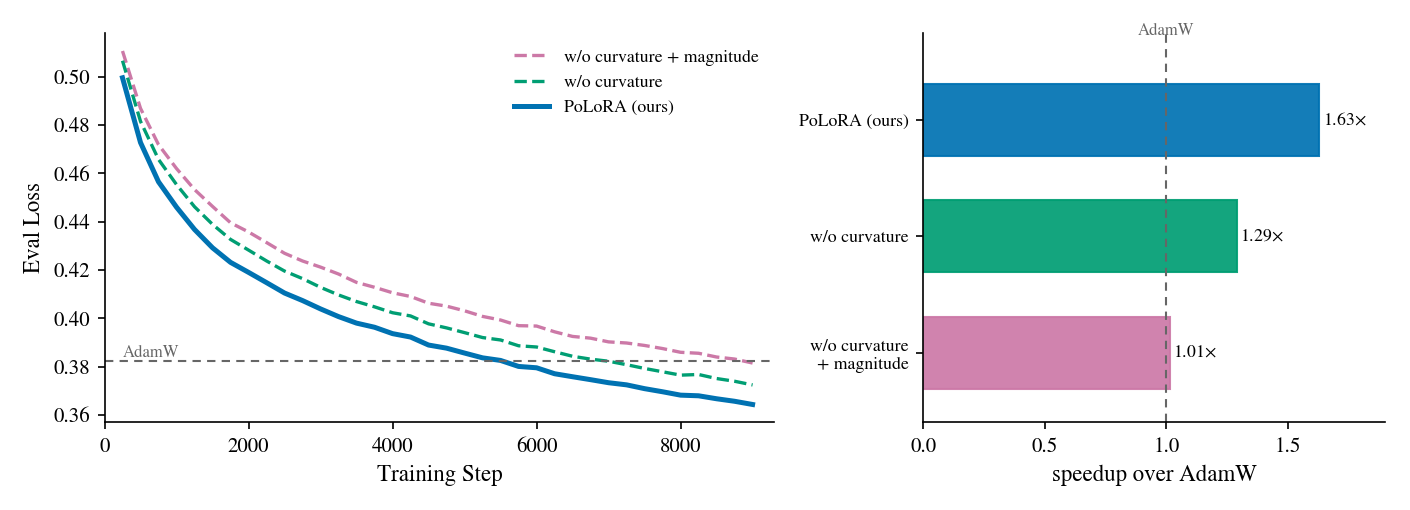

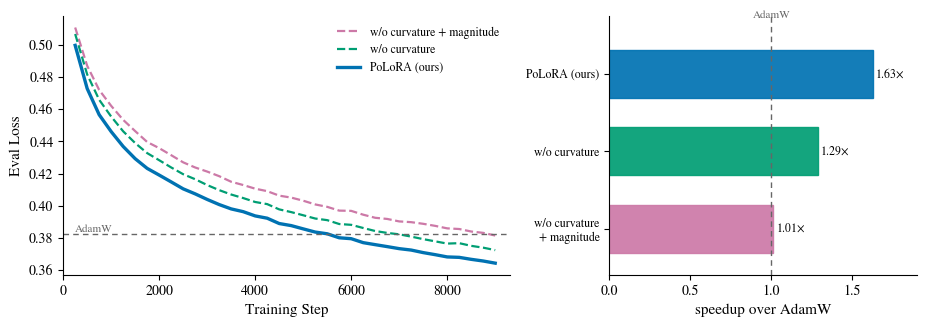

In [13]:
bpf.fig2()
display(Image(str(FIGS / 'fig2_ablation.png')))

## Figure 3 — lr basins across the openmath rank ladder

Shared lr axis across panels; per-panel y zoom; diverged points exit the frame top.

── fig3 lr transfer (openmath r>=32 ladder) ──
  r32 PoLoRA       best_lr 0.01  final 0.4000
  r32 AdamW        best_lr 0.0003  final 0.4115
  r64 PoLoRA       best_lr 0.01  final 0.3853
  r64 AdamW        best_lr 0.0001  final 0.3991
  r128 PoLoRA       best_lr 0.01  final 0.3743
  r128 AdamW        best_lr 0.0001  final 0.3890
  r256 PoLoRA       best_lr 0.01  final 0.3644
  r256 AdamW        best_lr 0.0001  final 0.3823


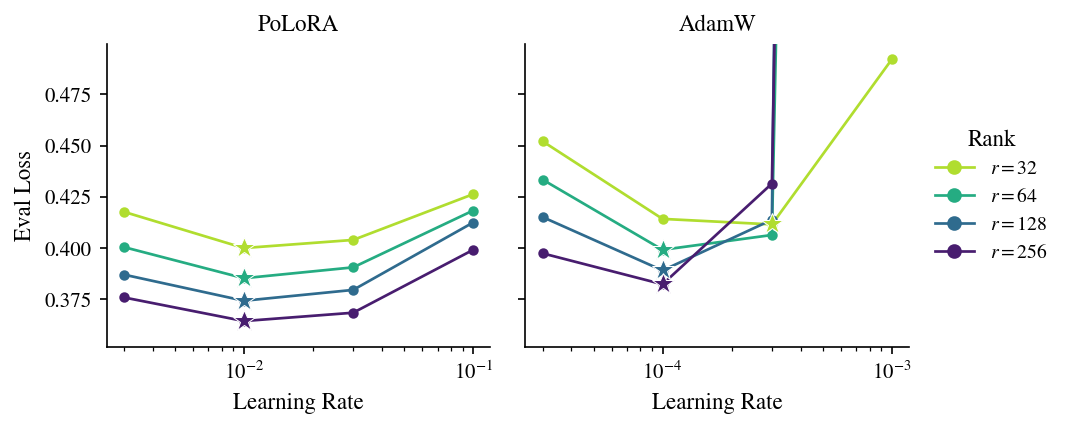

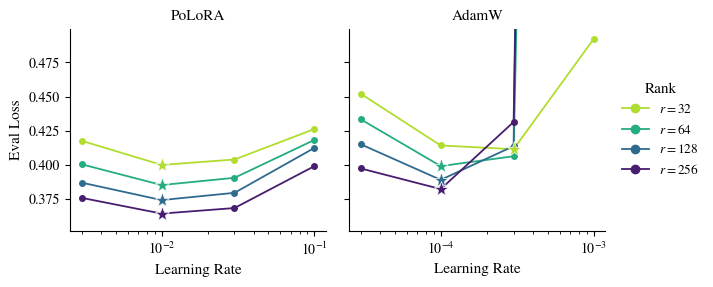

In [14]:
bpf.fig3()
display(Image(str(FIGS / 'fig3_lr_transfer.png')))